# 1 Import Packages

In [1]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pan

# Create Air Mixture Object
air = ct.Solution('gri30.yaml')

# Create Air Fuel Mixture for Wobbe Index
gas = ct.Solution('gri30.yaml')

# Create Air Fuel Mixture for Combustion Reaction
fuel1 = ct.Solution('gri30.yaml')

# 2 Stage 1 To Stage 6 Turbine

In [2]:
# Define Inlet Conditions to Compressor
P1 = 100000  # Pa (standard pressure)
T1 = 298  # K (standard temperature)

# Compressor Efficiency
Isen_Eff_Comp = 0.90

# Atomic Properties and Mole Fractions and Stoichiometric Combustion Parameters
CH4_Molecular_Weight=12.011+(4*(1.00784)) # Methane Molecular Weight
#H2_Molecular_Weight=2*(1.00784) # Hydrogen Molecular Weight
O2_Molecular_Weight=(2*(15.999)) # O2 Air Molecular Weight
N2_Molecular_Weight=(2*(14.0067)) # N2 Air Molecular Weight
CH4_fuel_stoic_mole=1.0
#H2_fuel_stoic_mole=1.0
O2_air_stoic_CH4_mole=2.0
#O2_air_stoic_H2_mole=0.5
O2_air_vol_mole_fraction=0.21
N2_air_vol_mole_fraction=0.79

# Calculate Mass of Fuel and Air for Stoichiometric Air-Fuel Ratio. Separate Stoichiometric Reactions CH4 + 2O2 -> CO2 + 2H2O and H2 + 0.5O2 -> H2O
mole_CH4_only_stoic_reaction=1.0
#mole_H2_only_stoic_reaction=1.0
CH4_stoic_mass = mole_CH4_only_stoic_reaction * CH4_Molecular_Weight
#H2_stoic_mass = mole_H2_only_stoic_reaction * H2_Molecular_Weight

O2_in_air_mole_stoic_CH4 = CH4_fuel_stoic_mole * O2_air_stoic_CH4_mole
air_total_mole_per_fuel = O2_in_air_mole_stoic_CH4/O2_air_vol_mole_fraction
mass_air_stoic_CH4 = air_total_mole_per_fuel * (O2_air_vol_mole_fraction * O2_Molecular_Weight + N2_air_vol_mole_fraction * N2_Molecular_Weight)

CH4_air_stoic_ratio =  CH4_stoic_mass/mass_air_stoic_CH4

#LHV of Fuel
# Set reactants state
gas.TPX = T1, P1, "CH4:1, O2:2"
h1 = gas.enthalpy_mass
Y_CH4 = gas["CH4"].Y[0]  # returns an array, of which we only want the first element

# Set state to complete combustion products without changing T or P
gas.TPX = None, None, "CO2:1, H2O:2"
h2 = gas.enthalpy_mass

LHV = -(h2 - h1) / Y_CH4 / 1e6 # [MJ/kg]

# Dictionary For Collecting Results for Analysis
Simulation_Results = {}

# Loop over Compressor Pressure Ratio (10 to 20)
for PR in range (10,21,1):  # Pressure ratio from 10 to 20 in steps of 1

# Combustion in Combustion Chamber
    # Loop over Equivalence Ratio from 0 to 1 in steps of 0.1
    for equi_phi in np.arange (0.1,1.1,0.1):
        
        # Loop over Hydrogen Percentage (0% to 100%)
        for CH4_frac in np.arange (0.1,1.1,0.1):  # Equivalence Ratio from 0% to 100% in steps of 10%

            # Define fuel mole fractions
            fuel_mole_fraction = {'CH4': CH4_frac}
            
            # Set fuel-air mixture
            air_mole_fractions = {'O2': 0.21, 'N2': 0.79}

            # Set Compressor Inlet State
            air.TPX=T1,P1, air_mole_fractions

            H1 = air.enthalpy_mass
            S1 = air.entropy_mass
            Density_air = air.density_mass # For Density of Air and Wobbe Index

            # Set Fuel to STP Conditions for Density of Fuel and Wobbe Index
            gas.TPX=T1,P1, fuel_mole_fraction
            Density_fuel = gas.density_mass # For Density of Fuel and Wobbe Index
            Wobbe_Index = LHV/(np.sqrt((Density_fuel/Density_air))) # [MJ/kg]

            # Isentropic Compression from P1 to P2
            P2 = P1*PR
            S2 = S1
            air.SP = S2, P2
            T2s = air.T

            # Find Specific Heat Capacity at Constant Pressure for Air for Computing Heat Gain By Cooling Air in Else Loop When T3 is Higher than T3_Max
            Air_Spec_Capacity_Cp = air.cp_mass

            # Isentropic Enthalpy After Compression
            H2s = air.enthalpy_mass

            # Actual Enthalpy After Compression
            H2 = H1 + ((H2s-H1)/Isen_Eff_Comp)

            # Set State of Air With Actual Enthalpy H2
            air.HP = H2, P2
            T2 = air.T
       
            # Find Mass of Fuel Using Mole Fraction From Actual Specified CH4_frac-H2_frac Volume Fraction Loop
            mass_of_CH4 = CH4_frac * CH4_Molecular_Weight

            mass_fuel = mass_of_CH4
  
            # Mass of Air From Compressor for Combustion 
            Comp_Mass_Air = mass_fuel/(equi_phi*CH4_air_stoic_ratio) # Mass of Air Compressed by Compressor for Combustion [kg]

            # If Combustor Exhaust Temperature is Lower Than The Maximum Turbine Inlet Temperature No Turbine Cooling
            mass_cooling_air = 0

            # Create New Air Fuel Mixture for Combustion Reaction
            fuel1 = ct.Solution('gri30.yaml')   

            # Set Mixture Temperature and Pressure To Premix Air and Fuel
            fuel1.TP=T2, P2

            # Simulate the Combustion to Calculate Temperature, T3 of The Combustion Gas
            fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

            # Combust the Air-Fuel Mixture At Constant Enthalpy To Obtain Combustion Gases Temperature T3
            fuel1.equilibrate('HP')

            # Find Mole Fractions of Reaction Products:CO2, H2O, N2, NOx and SOx Formation Before Cooling
            mole_fraction_CO2_Before_Cooling = fuel1['CO2'].X[0]
            mole_fraction_N2_Before_Cooling = fuel1['N2'].X[0]
            mole_fraction_H2O_Before_Cooling = fuel1['H2O'].X[0]
            mole_fraction_NO_Before_Cooling = fuel1['NO'].X[0]
            mole_fraction_NO2_Before_Cooling = fuel1['NO2'].X[0]
            mole_fraction_NOx_Before_Cooling = mole_fraction_NO_Before_Cooling + mole_fraction_NO2_Before_Cooling
            
            # mole_fraction_SO2 = fuel1['SO2'].X[0]
            # mole_fraction_SO3 = fuel1['SO3'].X[0]
            # mole_fraction_SOx = mole_fraction_SO2 + mole_fraction_SO3

            mass_fraction_CO2_Before_Cooling = fuel1['CO2'].Y[0]
            mass_fraction_N2_Before_Cooling = fuel1['N2'].Y[0]
            mass_fraction_H2O_Before_Cooling = fuel1['H2O'].Y[0]
            mass_fraction_NO_Before_Cooling = fuel1['NO'].Y[0]
            mass_fraction_NO2_Before_Cooling = fuel1['NO2'].Y[0]
            mass_fraction_NOx_Before_Cooling = mass_fraction_NO_Before_Cooling + mass_fraction_NO2_Before_Cooling

            # mass_fraction_SO2 = fuel1['SO2'].Y[0]
            # mass_fraction_SO3 = fuel1['SO3'].Y[0]
            # mass_fraction_SOx = mass_fraction_SO2 + mass_fraction_SO3

            # Adiabetic Flame Temperature        
            T3 = fuel1.T

            # Equlibrate at T3, Adiabetic Flame Temperature To Get Heat Added by Combustion
            # Set Mixture Temperature and Pressure of Premix Air and Fuel to Adiabetic flame Temperature, T3 and P2
            fuel1.TP=T3, P2

            # Simulate the Combustion to Calculate Enthalpy, H3 of The Combustion Gas
            fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

            # Find Enthalpy and Entropy After Combustion at T3 and P2.
            H3 = fuel1.enthalpy_mass
            H3_Collecting_Results = H3 # For Plotting
            S3 = fuel1.entropy_mass

            T3_Max = 2000 # Maximum Turbine Inlet Temperature. Calculate Cooling Air if T3 Exceeds T3_Max
            mass_cooling_air = 0 # If Combustor Exhaust Temperature is Higher Than The Maximum Turbine Inlet Temperature

            # Compressor Work, Combustion Energy and Turbine Work If Combustion Gas Temperatures are Below Maximum Turbine Inlet Temperature
            if T3<=T3_Max:
                #Actual T3 Values for Analysis
                T3_Actual=T3
                
                # Calculate Compressor Air for Combustion
                mass_cooling_air = 0 # If Combustor Exhaust Temperature is Higher Than The Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max

                Comp_Mass_Air_Cooling = Comp_Mass_Air + mass_cooling_air # mass_cooling_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max          
                mass_fuel_air_in_combustor_turbine = Comp_Mass_Air + mass_cooling_air + mass_fuel # mass_cooling_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max

                # Compressor Work With Air Flow Accounted For. In Compressor, Gas Is Only Air
                W_Comp=Comp_Mass_Air_Cooling*Isen_Eff_Comp*(H2-H1)

                # Compute Heat Added
                Heat_in=mass_fuel_air_in_combustor_turbine*(H3-H2)

                # Turbine Section Isentropic Expansion
                Isen_Eff_Turb = 0.90 # Turbine Efficiency

                # Reset the Combustion Mixture in the Turbine to S3 and P1, Exhaust Pressure               
                S4 = S3
                fuel1.SP = S4, P1
                
                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)
                
                # Isentropic Enthalpy After Expansion in Turbine                
                H4s = fuel1.enthalpy_mass

                # Actual Enthalpy After Expansion in Turbine
                H4 = H3 - Isen_Eff_Turb * (H3 - H4s)   

                # Turbine Work
                W_Turb = mass_fuel_air_in_combustor_turbine*Isen_Eff_Turb*(H3-H4)

                # Gas Turbine Efficiency
                Net_Work = W_Turb-W_Comp
                Cycle_Eff = Net_Work/Heat_in

                # Mole Fractions of Reaction Products Same As Above Because No Recombustion To Account for Turbine Cooling 

            # Compressor Work, Combustion Energy and Turbine Work If Combustion Gas Temperatures are Above Maximum Turbine Inlet Temperature
            elif T3>T3_Max:
                # If T3 > T3_Max, Then Cool The Combustion Gases. H2 of Compresssed Air Remains the Same. Stoichiometric Air-Fuel Ratio Also Remains the Same Because Combustion has Already Occured, the Extra Air is Just for Cooling
                # Solve for Cooling Air Mass That Is Heated From T3_Max to T3, Temperature Above T3_Max. This Is Equal To Energy Gained By Cooling Air To Cool The Combustion Gas from Temperature T3, Above T3_Max to T3_Max
                H_Above_T3_Max = H3

                # Set Combusted Mixture To T3_Max and P2 for Calculating Difference in Enthalpy from H_Above_T3_Max and H3_Max
                fuel1.TP=T3_Max, P2
                
                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

                H3_Max = fuel1.enthalpy_mass # Target Enthalpy
                H3_Collecting_Results = H3 # For Plotting
                S3_Max = fuel1.entropy_mass

                # Find Mass of Cooling Air From Change in Enthalpy of Cooling Air Which is Cooled at Constant Pressure i.e. H_Cooling=mass_cooling_air*cp(T3-T3_Max)
                H_Cooling_Energy = H_Above_T3_Max - H3_Max
                mass_cooling_air = H_Cooling_Energy/(Air_Spec_Capacity_Cp*(T3-T3_Max))

                # New Compressor Air with Cooling Air
                Comp_Mass_Air_Cooling = Comp_Mass_Air + mass_cooling_air

                mass_fuel_air_cooling_air_in_turbine = mass_fuel + Comp_Mass_Air_Cooling # mass_cooling_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Mass of Cooling Air is Calculated in This Loop Because T3 > T3_Max

                # Mass of Fuel and Combustion Air From Compressor for Heat_In Calculation
                mass_fuel_air_in_combustor = Comp_Mass_Air + mass_fuel # mass_cool is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Mass of Cooling Air is Calculated in This Loop Because T3 > T3_Max

                # Not Recombusting. Reduce Enthalpy H3 by H_Cooling_Energy by Setting H3 to H3_Max, Heat_in Accounts for Energy For Cooling by Reducing the Enthalpy of the Combustion gas from H3 to H3_Max, Hence Reduced Work Extraction by the Turbine
                Heat_in = mass_fuel_air_in_combustor*(H3-H2)

                #Actual T3 Values for Analysis
                T3_Actual=T3

                # Set T3 to T3_Max for Plotting T3 Values
                T3=T3_Max

                # Compressor Work With Cooling Air Accounted For. In Compressor, Gas Is Only Air
                W_Comp=Comp_Mass_Air_Cooling*Isen_Eff_Comp*(H2-H1)

                # Turbine Section Isentropic Expansion
                Isen_Eff_Turb = 0.90 # Turbine Efficiency                

                # Set Combusted Mixture To S3_Max at Lower Energy Level of Cooled Combustion Gases Before Entering Turbine and Atmospheric Pressure, P1 for Expansion in Turbine
                S4 = S3_Max

                fuel1.SP = S4, P1

                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)
                
                # Isentropic Enthalpy After Expansion in Turbine                
                H4s = fuel1.enthalpy_mass

                # Actual Enthalpy After Expansion in Turbine
                H4 = H3_Max - Isen_Eff_Turb*(H3_Max-H4s)

                # Turbine Work. Reduce Enthalpy H3 by H_Cooling_Energy by Setting H3 to H3_Max, Heat_in Accounts for Energy For Cooling by Reduce the Enthalpy of the Combustion gas from H3 to H3_Max, Hence Reduced Work Extraction by the Turbine
                W_Turb = mass_fuel_air_cooling_air_in_turbine*Isen_Eff_Turb*(H3_Max-H4)                

                # Gas Turbine Efficiency
                Net_Work = W_Turb-W_Comp
                Cycle_Eff = Net_Work/Heat_in

            else:
                print("Error T3 is Not Positive")

            # For Collecting Results for Analysis
            Simulation_Results[(PR, equi_phi, CH4_frac)] = {
                "Equivalence_Ratio":equi_phi,
                "CH4_Mole_Fraction":CH4_frac,
                "Mass_Fuel_Air":mass_fuel_air_in_combustor_turbine,
                "Combustion_Gas_Temperature":T3,
                "Actual_Combustion_Temperature":T3_Actual,
                "H3_Entering_Turbine": H3_Collecting_Results,
                "H4_Exhaust": H4,
                "Cycle_Efficiency":Cycle_Eff,
                "Mole_Fraction_of_Methane":CH4_frac,
                "Pressure_Ratio":PR,
                "CO2_Mole_Fraction":mole_fraction_CO2_Before_Cooling,
                "N2_Mole_Fraction":mole_fraction_N2_Before_Cooling,
                "NOx_Mole_Fraction":mole_fraction_NOx_Before_Cooling,
                #"SOX_mole_fraction":mole_fraction_SOx_Before_Cooling,
                "H2O_Mole_Fraction":mole_fraction_H2O_Before_Cooling,
                "CO2_Mass_Fraction":mass_fraction_CO2_Before_Cooling,
                "N2_Mass_Fraction":mass_fraction_N2_Before_Cooling,
                "NOx_Mass_Fraction":mass_fraction_NOx_Before_Cooling,
                #"SOx_mass_fraction":mass_fraction_SOx_Before_Cooling,       
                "H2O_Mass_Fraction":mass_fraction_H2O_Before_Cooling,
                "Compressor_Work":W_Comp,
                "Compressor_Air_Mass":Comp_Mass_Air_Cooling,
                "Cooling_Air_Mass":mass_cooling_air,
                "Heat_in":Heat_in,
                "Turbine_Work":W_Turb,
                "Net_Work":Net_Work,
                "LHV":LHV,
                "Wobbe_Index":Wobbe_Index
                }
Simulation_Results_df = pan.DataFrame.from_dict(Simulation_Results, "index")

# Get Index Names of Set Values

In [3]:
print(Simulation_Results_df.shape)
Simulation_Results_df.info()

(1100, 26)
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1100 entries, (np.int64(10), np.float64(0.1), np.float64(0.1)) to (np.int64(20), np.float64(1.0), np.float64(1.0))
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Equivalence_Ratio              1100 non-null   float64
 1   CH4_Mole_Fraction              1100 non-null   float64
 2   Mass_Fuel_Air                  1100 non-null   float64
 3   Combustion_Gas_Temperature     1100 non-null   float64
 4   Actual_Combustion_Temperature  1100 non-null   float64
 5   H3_Entering_Turbine            1100 non-null   float64
 6   H4_Exhaust                     1100 non-null   float64
 7   Cycle_Efficiency               1100 non-null   float64
 8   Mole_Fraction_of_Methane       1100 non-null   float64
 9   Pressure_Ratio                 1100 non-null   int64  
 10  CO2_Mole_Fraction              1100 non-null   float64
 11  N2_Mol

# 3 Pandas Data Analysis/Plot Graphs

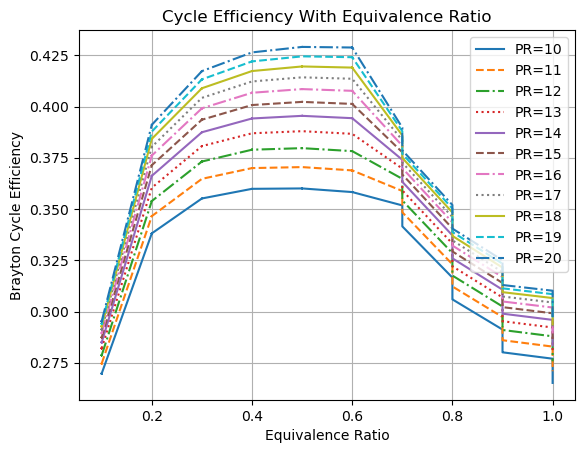

Maximum Cycle Efficiency': 0.4290782234218076
Minimum Cycle Efficiency': 0.26516550209036316


In [4]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.Cycle_Efficiency, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Brayton Cycle Efficiency')
plt.title('Cycle Efficiency With Equivalence Ratio')
plt.grid()
plt.show()

Max_Cycle_Efficiency = Simulation_Results_df['Cycle_Efficiency'].max()
print(f"Maximum Cycle Efficiency': {Max_Cycle_Efficiency}")

Min_Cycle_Efficiency = Simulation_Results_df['Cycle_Efficiency'].min()
print(f"Minimum Cycle Efficiency': {Min_Cycle_Efficiency}")

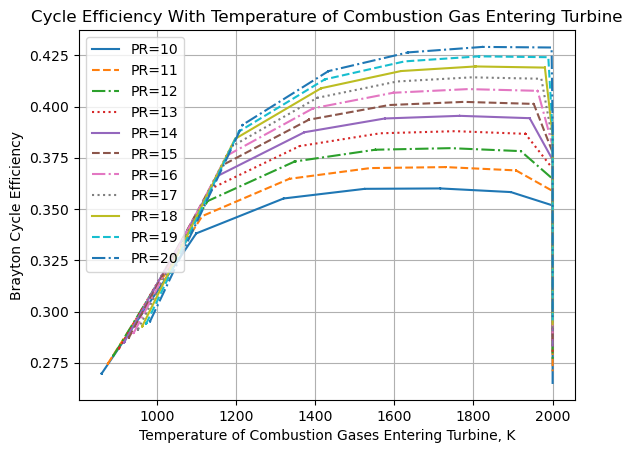

Maximum Cycle Efficiency': 0.4290782234218076
Minimum Cycle Efficiency': 0.26516550209036316


In [5]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Combustion_Gas_Temperature, df_temp.Cycle_Efficiency, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Temperature of Combustion Gases Entering Turbine, K')
plt.ylabel('Brayton Cycle Efficiency')
plt.title('Cycle Efficiency With Temperature of Combustion Gas Entering Turbine')
plt.grid()
plt.show()

Max_Cycle_Efficiency = Simulation_Results_df['Cycle_Efficiency'].max()
print(f"Maximum Cycle Efficiency': {Max_Cycle_Efficiency}")

Min_Cycle_Efficiency = Simulation_Results_df['Cycle_Efficiency'].min()
print(f"Minimum Cycle Efficiency': {Min_Cycle_Efficiency}")

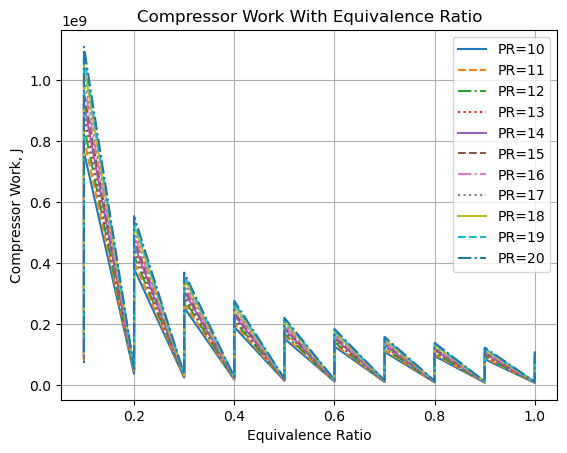

Maximum Compressor Work': 1109273269.6818683
Minimum Compressor Work': 8068797.12836965


In [6]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.Compressor_Work, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Compressor Work, J')
plt.title('Compressor Work With Equivalence Ratio')
plt.grid()
plt.show()

Max_Compressor_Work = Simulation_Results_df['Compressor_Work'].max()
print(f"Maximum Compressor Work': {Max_Compressor_Work}")

Min_Compressor_Work = Simulation_Results_df['Compressor_Work'].min()
print(f"Minimum Compressor Work': {Min_Compressor_Work}")

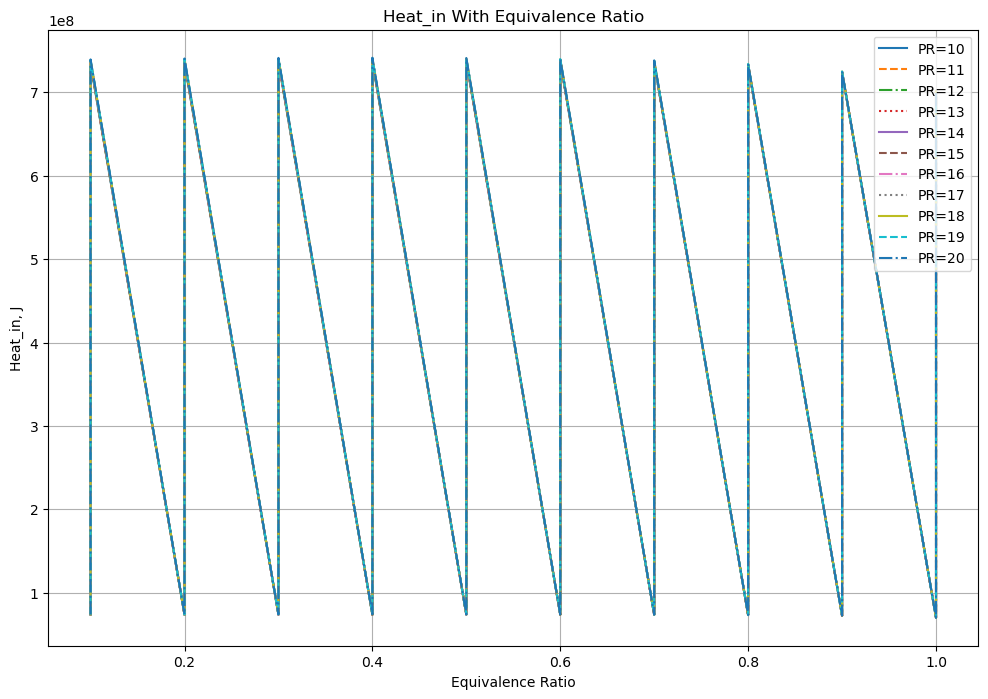

Maximum Heat In': 741566100.2117294
Minimum Heat In': 70040433.81518672


In [7]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure(figsize=(12, 8))
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.Heat_in, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Heat_in, J')
plt.title('Heat_in With Equivalence Ratio')
plt.grid()
plt.show()

Max_Heat_In = Simulation_Results_df['Heat_in'].max()
print(f"Maximum Heat In': {Max_Heat_In}")

Min_Heat_In = Simulation_Results_df['Heat_in'].min()
print(f"Minimum Heat In': {Min_Heat_In}")

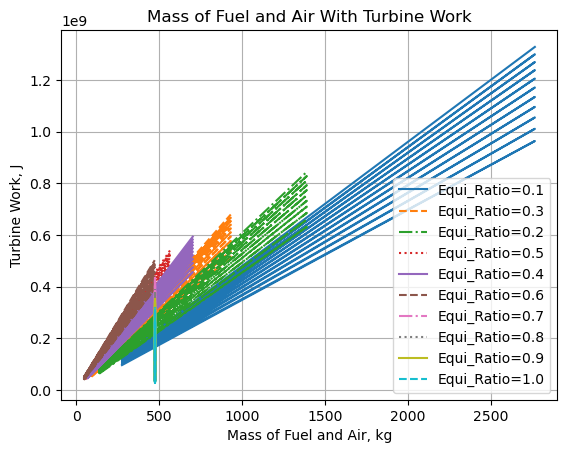

Maximum Mass_Fuel_Air': 2763.677217142857
Minimum Mass_Fuel_Air': 47.398150285714294


In [8]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Equivalence_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Equivalence_Ratio==v].copy()
    plt.plot(df_temp.Mass_Fuel_Air, df_temp.Turbine_Work, label=f"Equi_Ratio={round(v,1)}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Mass of Fuel and Air, kg')
plt.ylabel('Turbine Work, J')
plt.title('Mass of Fuel and Air With Turbine Work')
plt.grid()
plt.show()

Max_Mass_Fuel_Air = Simulation_Results_df['Mass_Fuel_Air'].max()
print(f"Maximum Mass_Fuel_Air': {Max_Mass_Fuel_Air}")

Min_Mass_Fuel_Air = Simulation_Results_df['Mass_Fuel_Air'].min()
print(f"Minimum Mass_Fuel_Air': {Min_Mass_Fuel_Air}")

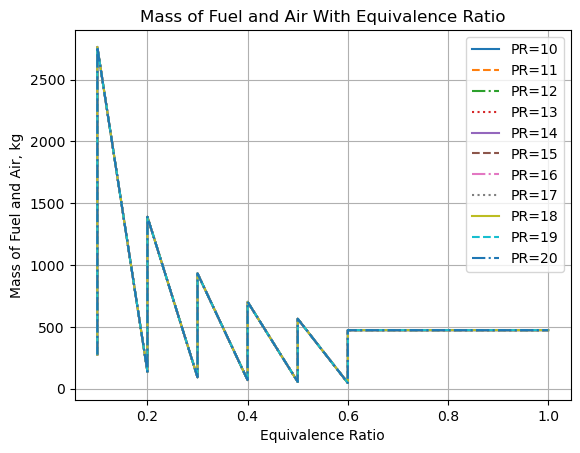

Maximum Mass_Fuel_Air': 2763.677217142857
Minimum Mass_Fuel_Air': 47.398150285714294


In [9]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.Mass_Fuel_Air, label=f"PR={round(v,1)}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Mass of Fuel and Air, kg')
plt.title('Mass of Fuel and Air With Equivalence Ratio')
plt.grid()
plt.show()

Max_Mass_Fuel_Air = Simulation_Results_df['Mass_Fuel_Air'].max()
print(f"Maximum Mass_Fuel_Air': {Max_Mass_Fuel_Air}")

Min_Mass_Fuel_Air = Simulation_Results_df['Mass_Fuel_Air'].min()
print(f"Minimum Mass_Fuel_Air': {Min_Mass_Fuel_Air}")

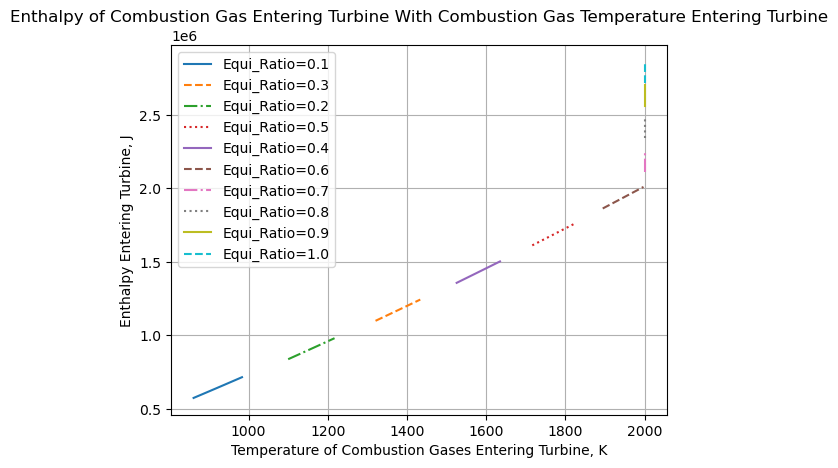

Maximum H3_Entering_Turbine': 2860333.049329246
Minimum H3_Entering_Turbine': 575046.2617176487


In [10]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Equivalence_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Equivalence_Ratio==v].copy()
    plt.plot(df_temp.Combustion_Gas_Temperature, df_temp.H3_Entering_Turbine, label=f"Equi_Ratio={round(v,1)}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Temperature of Combustion Gases Entering Turbine, K')
plt.ylabel('Enthalpy Entering Turbine, J')
plt.title('Enthalpy of Combustion Gas Entering Turbine With Combustion Gas Temperature Entering Turbine')
plt.grid()
plt.show()

Max_H3_Entering_Turbine = Simulation_Results_df['H3_Entering_Turbine'].max()
print(f"Maximum H3_Entering_Turbine': {Max_H3_Entering_Turbine}")

Min_H3_Entering_Turbine = Simulation_Results_df['H3_Entering_Turbine'].min()
print(f"Minimum H3_Entering_Turbine': {Min_H3_Entering_Turbine}")

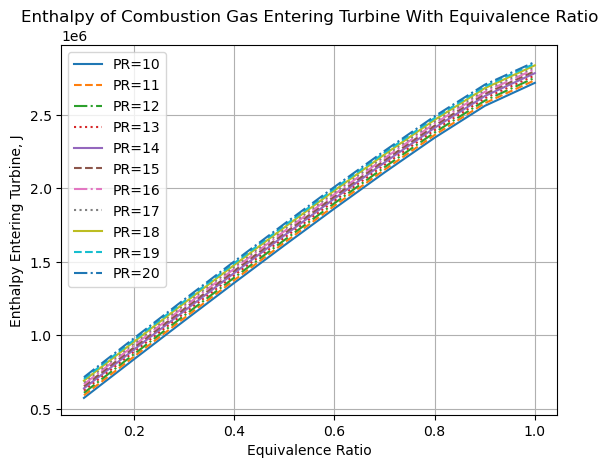

Maximum H3_Entering_Turbine': 2860333.049329246
Minimum H3_Entering_Turbine': 575046.2617176487


In [11]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.H3_Entering_Turbine, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Enthalpy Entering Turbine, J')
plt.title('Enthalpy of Combustion Gas Entering Turbine With Equivalence Ratio')
plt.grid()
plt.show()

Max_H3_Entering_Turbine = Simulation_Results_df['H3_Entering_Turbine'].max()
print(f"Maximum H3_Entering_Turbine': {Max_H3_Entering_Turbine}")

Min_H3_Entering_Turbine = Simulation_Results_df['H3_Entering_Turbine'].min()
print(f"Minimum H3_Entering_Turbine': {Min_H3_Entering_Turbine}")

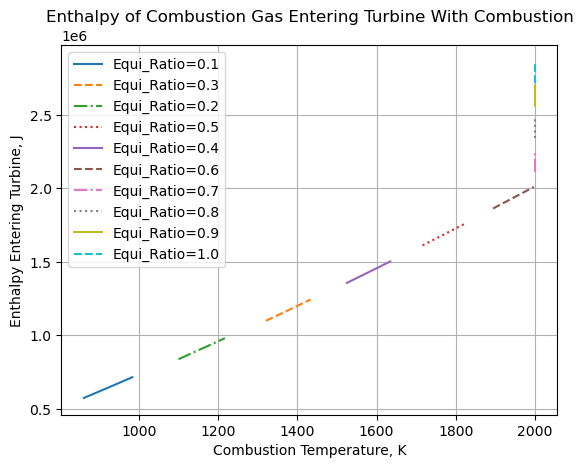

Maximum H3_Entering_Turbine': 2860333.049329246
Minimum H3_Entering_Turbine': 575046.2617176487


In [12]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Equivalence_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Equivalence_Ratio==v].copy()
    plt.plot(df_temp.Combustion_Gas_Temperature, df_temp.H3_Entering_Turbine, label=f"Equi_Ratio={round(v,1)}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Combustion Temperature, K')
plt.ylabel('Enthalpy Entering Turbine, J')
plt.title('Enthalpy of Combustion Gas Entering Turbine With Combustion')
plt.grid()
plt.show()

Max_H3_Entering_Turbine = Simulation_Results_df['H3_Entering_Turbine'].max()
print(f"Maximum H3_Entering_Turbine': {Max_H3_Entering_Turbine}")

Min_H3_Entering_Turbine = Simulation_Results_df['H3_Entering_Turbine'].min()
print(f"Minimum H3_Entering_Turbine': {Min_H3_Entering_Turbine}")

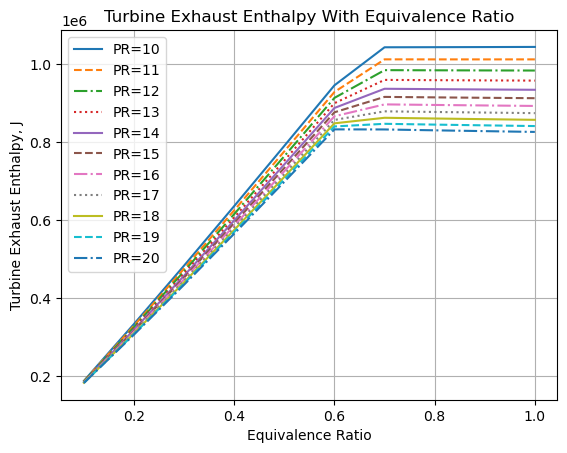

Maximum H4_Exhaust': 1044241.3097763389
Minimum H4_Exhaust': 182289.6531165432


In [13]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.H4_Exhaust, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Turbine Exhaust Enthalpy, J')
plt.title('Turbine Exhaust Enthalpy With Equivalence Ratio')
plt.grid()
plt.show()

Max_H4_Exhaust = Simulation_Results_df['H4_Exhaust'].max()
print(f"Maximum H4_Exhaust': {Max_H4_Exhaust}")

Min_H4_Exhaust = Simulation_Results_df['H4_Exhaust'].min()
print(f"Minimum H4_Exhaust': {Min_H4_Exhaust}")

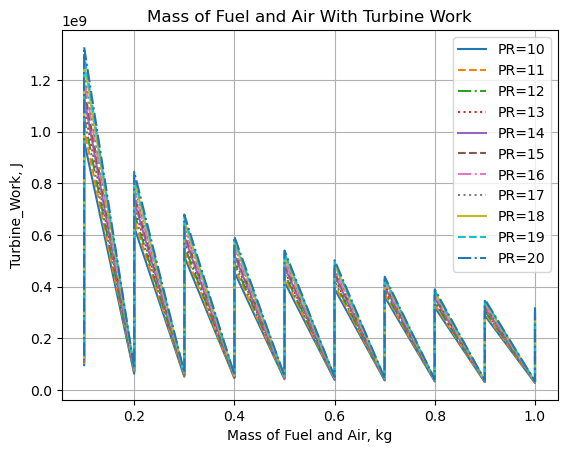

Maximum Turbine Work': 1327597754.2374587
Minimum Turbine Work': 27468701.105120935


In [14]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.Turbine_Work, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Mass of Fuel and Air, kg')
plt.ylabel('Turbine_Work, J')
plt.title('Mass of Fuel and Air With Turbine Work')
plt.grid()
plt.show()

Max_Turbine_Work = Simulation_Results_df['Turbine_Work'].max()
print(f"Maximum Turbine Work': {Max_Turbine_Work}")

Min_Turbine_Work = Simulation_Results_df['Turbine_Work'].min()
print(f"Minimum Turbine Work': {Min_Turbine_Work}")

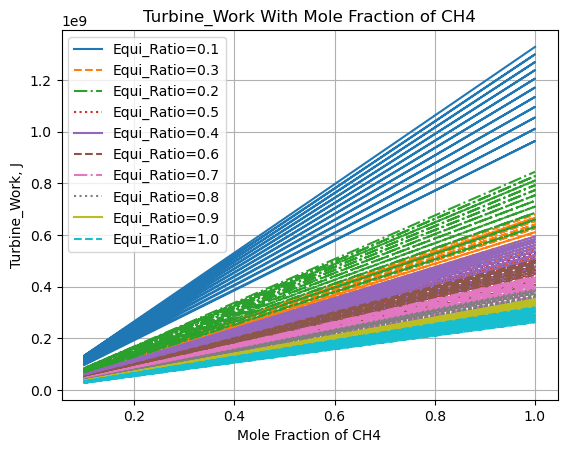

Maximum Turbine Work': 1327597754.2374587
Minimum Turbine Work': 27468701.105120935


In [15]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Equivalence_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Equivalence_Ratio==v].copy()
    plt.plot(df_temp.CH4_Mole_Fraction, df_temp.Turbine_Work, label=f"Equi_Ratio={round(v,1)}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Mole Fraction of CH4')
plt.ylabel('Turbine_Work, J')
plt.title('Turbine_Work With Mole Fraction of CH4')
plt.grid()
plt.show()

Max_Turbine_Work = Simulation_Results_df['Turbine_Work'].max()
print(f"Maximum Turbine Work': {Max_Turbine_Work}")

Min_Turbine_Work = Simulation_Results_df['Turbine_Work'].min()
print(f"Minimum Turbine Work': {Min_Turbine_Work}")

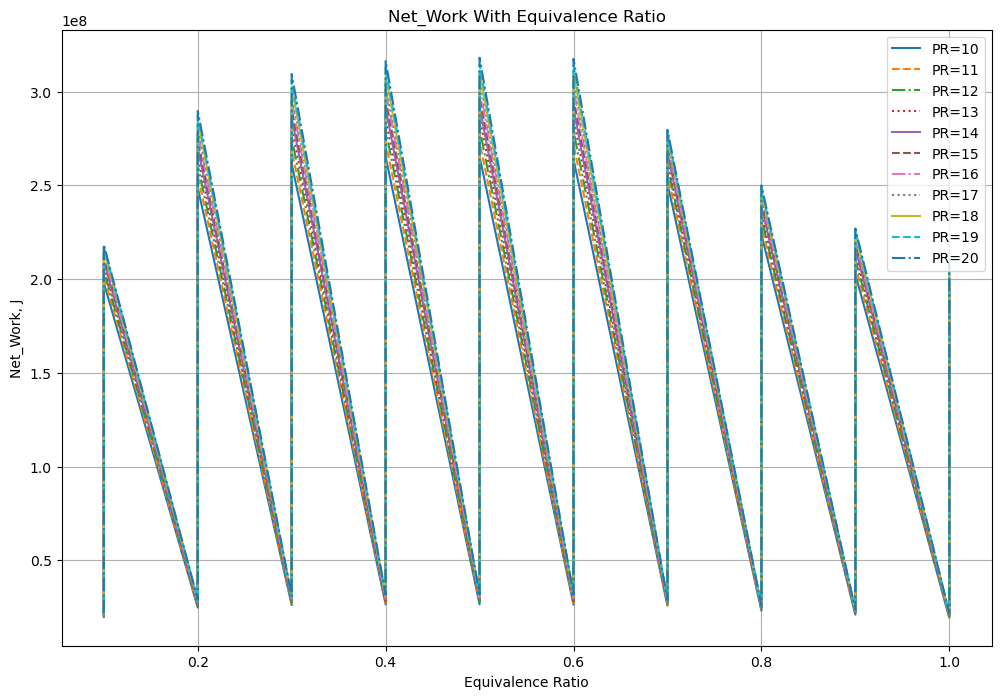

Maximum Net Work': 318041873.60955167
Minimum Net Work': 19399903.976751283


In [16]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure(figsize=(12, 8))
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.Net_Work, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Net_Work, J')
plt.title('Net_Work With Equivalence Ratio')
plt.grid()
plt.show()

Max_Cycle_Efficiency = Simulation_Results_df['Net_Work'].max()
print(f"Maximum Net Work': {Max_Cycle_Efficiency}")

Min_Cycle_Efficiency = Simulation_Results_df['Net_Work'].min()
print(f"Minimum Net Work': {Min_Cycle_Efficiency}")

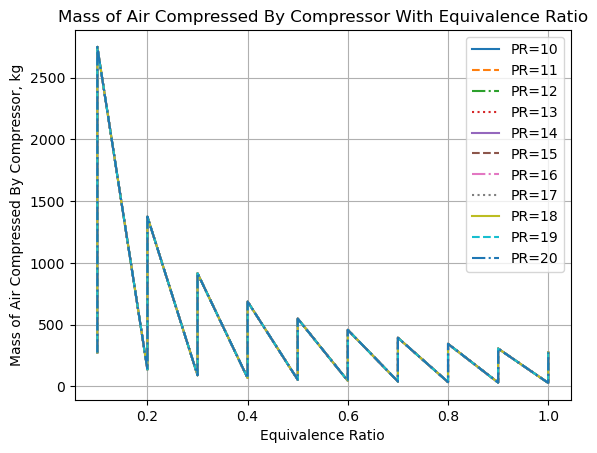

Maximum Mass of Air Compressed In Compressor': 2747.634857142857
Minimum Mass of Air Compressed In Compressor': 28.92677331382192


In [17]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.Compressor_Air_Mass, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Mass of Air Compressed By Compressor, kg')
plt.title('Mass of Air Compressed By Compressor With Equivalence Ratio')
plt.grid()
plt.show()

Max_Mass_Air_Compressed = Simulation_Results_df['Compressor_Air_Mass'].max()
print(f"Maximum Mass of Air Compressed In Compressor': {Max_Mass_Air_Compressed}")

Min_Mass_Air_Compressed = Simulation_Results_df['Compressor_Air_Mass'].min()
print(f"Minimum Mass of Air Compressed In Compressor': {Min_Mass_Air_Compressed}")

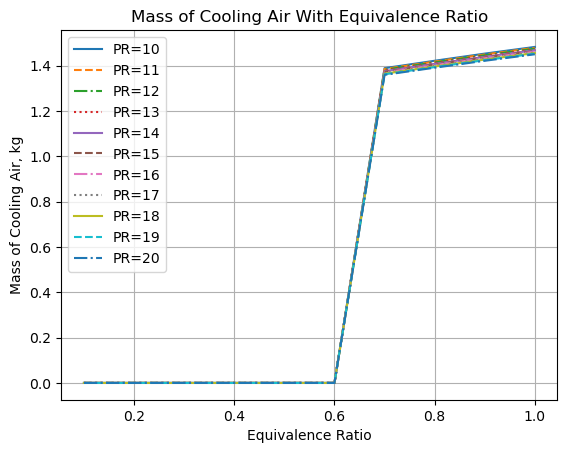

Maximum Mass of Cooling Air': 1.4828688626101378
Minimum Mass of Cooling Air': 0.0


In [18]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.Cooling_Air_Mass, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Mass of Cooling Air, kg')
plt.title('Mass of Cooling Air With Equivalence Ratio')
plt.grid()
plt.show()

Max_Cooling_Air_Mass = Simulation_Results_df['Cooling_Air_Mass'].max()
print(f"Maximum Mass of Cooling Air': {Max_Cooling_Air_Mass}")

Min_Cooling_Air_Mass = Simulation_Results_df['Cooling_Air_Mass'].min()
print(f"Minimum Mass of Cooling Air': {Min_Cooling_Air_Mass}")

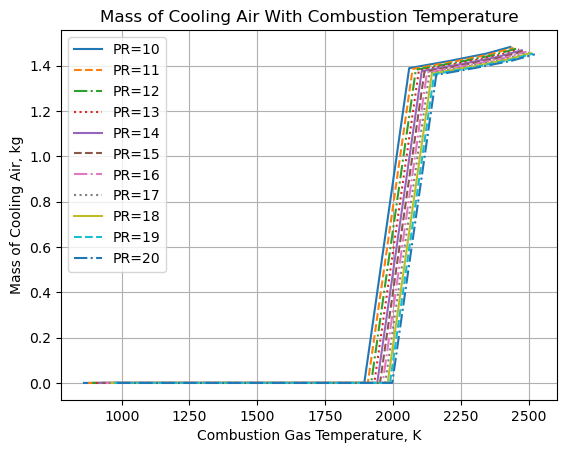

Maximum Mass of Cooling Air': 1.4828688626101378
Minimum Mass of Cooling Air': 0.0


In [19]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Actual_Combustion_Temperature, df_temp.Cooling_Air_Mass, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Combustion Gas Temperature, K')
plt.ylabel('Mass of Cooling Air, kg')
plt.title('Mass of Cooling Air With Combustion Temperature')
plt.grid()
plt.show()

Max_Cooling_Air_Mass = Simulation_Results_df['Cooling_Air_Mass'].max()
print(f"Maximum Mass of Cooling Air': {Max_Cooling_Air_Mass}")

Min_Cooling_Air_Mass = Simulation_Results_df['Cooling_Air_Mass'].min()
print(f"Minimum Mass of Cooling Air': {Min_Cooling_Air_Mass}")

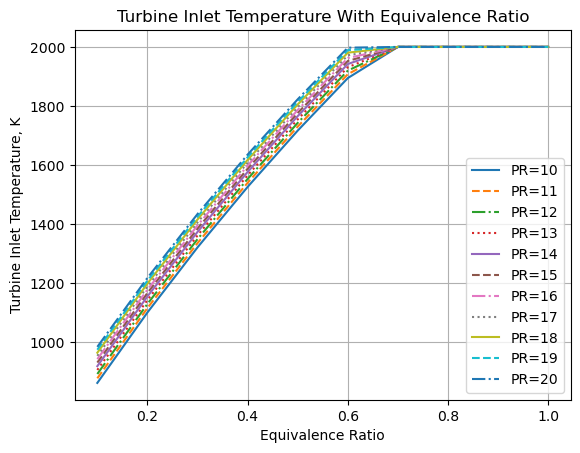

Maximum Combustion Gas Temperature': 2000.0
Minimum Combustion Gas Temperature': 860.8621572009798


In [20]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.Combustion_Gas_Temperature, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Turbine Inlet Temperature, K')
plt.title('Turbine Inlet Temperature With Equivalence Ratio')
plt.grid()
plt.show()

Max_Combustion_Gas_Temperature = Simulation_Results_df['Combustion_Gas_Temperature'].max()
print(f"Maximum Combustion Gas Temperature': {Max_Combustion_Gas_Temperature}")

Min_Combustion_Gas_Temperature = Simulation_Results_df['Combustion_Gas_Temperature'].min()
print(f"Minimum Combustion Gas Temperature': {Min_Combustion_Gas_Temperature}")

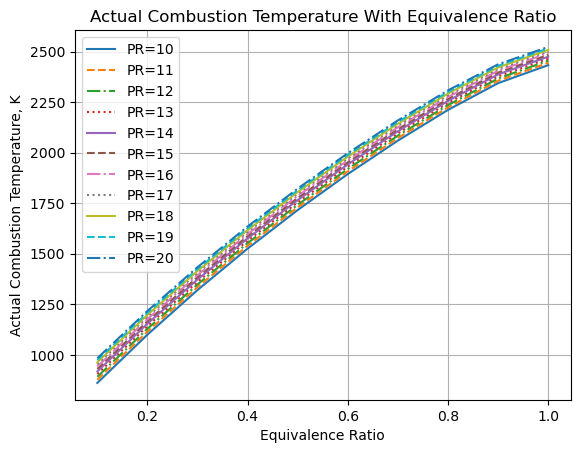

Maximum Actual Combustion Temperature': 2523.2591561245686
Minimum Actual Combustion Temperature': 860.8621572009798


In [21]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.Actual_Combustion_Temperature, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('Actual Combustion Temperature, K')
plt.title('Actual Combustion Temperature With Equivalence Ratio')
plt.grid()
plt.show()

Max_Actual_Combustion_Temperature = Simulation_Results_df['Actual_Combustion_Temperature'].max()
print(f"Maximum Actual Combustion Temperature': {Max_Actual_Combustion_Temperature}")

Min_Actual_Combustion_Temperature = Simulation_Results_df['Actual_Combustion_Temperature'].min()
print(f"Minimum Actual Combustion Temperature': {Min_Actual_Combustion_Temperature}")

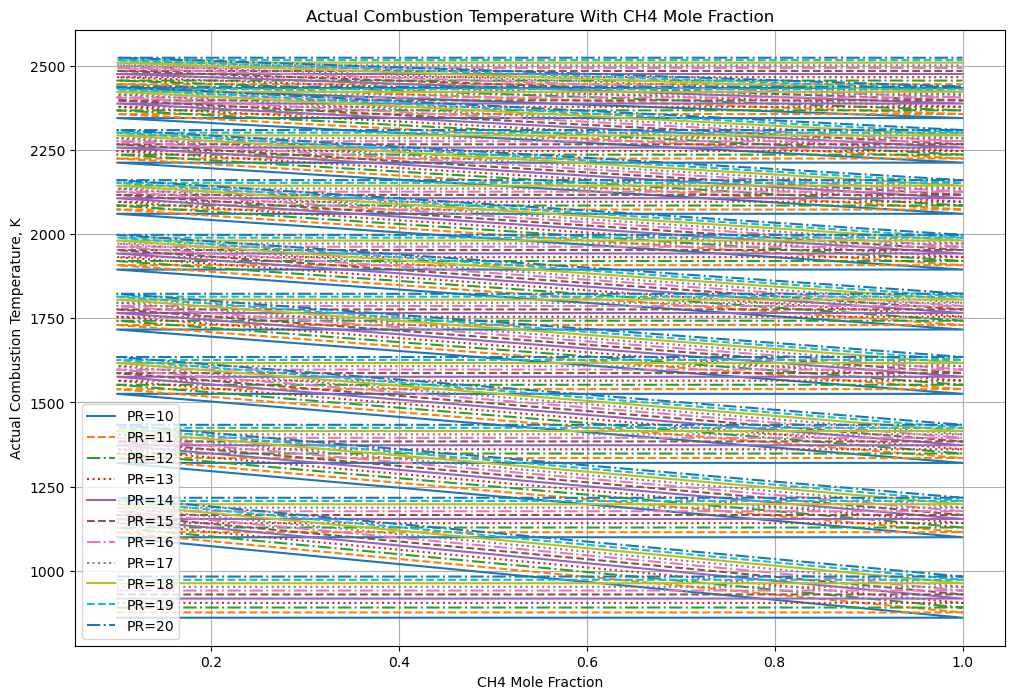

Maximum Actual Combustion Temperature': 2523.2591561245686
Minimum Actual Combustion Temperature': 860.8621572009798


In [22]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure(figsize=(12, 8))
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.CH4_Mole_Fraction, df_temp.Actual_Combustion_Temperature, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('CH4 Mole Fraction')
plt.ylabel('Actual Combustion Temperature, K')
plt.title('Actual Combustion Temperature With CH4 Mole Fraction')
plt.grid()
plt.show()

Max_Actual_Combustion_Temperature = Simulation_Results_df['Actual_Combustion_Temperature'].max()
print(f"Maximum Actual Combustion Temperature': {Max_Actual_Combustion_Temperature}")

Min_Actual_Combustion_Temperature = Simulation_Results_df['Actual_Combustion_Temperature'].min()
print(f"Minimum Actual Combustion Temperature': {Min_Actual_Combustion_Temperature}")

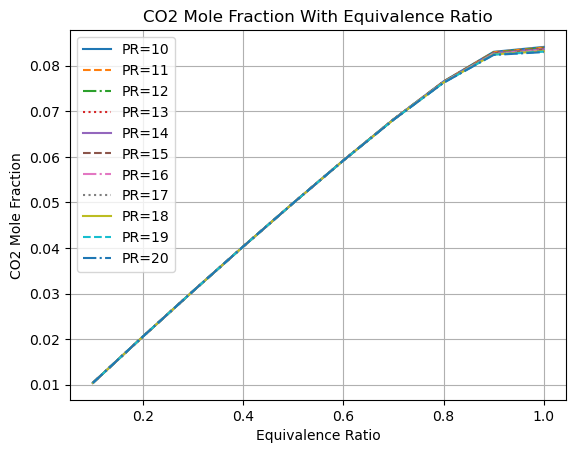

Maximum CO2 Mole Fraction': 0.08412736120328208
Minimum CO2 Mole Fraction': 0.0103909084551334


In [23]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.CO2_Mole_Fraction, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('CO2 Mole Fraction')
plt.title('CO2 Mole Fraction With Equivalence Ratio')
plt.grid()
plt.show()

Max_CO2_Mole_Fraction = Simulation_Results_df['CO2_Mole_Fraction'].max()
print(f"Maximum CO2 Mole Fraction': {Max_CO2_Mole_Fraction}")

Min_CO2_Mole_Fraction = Simulation_Results_df['CO2_Mole_Fraction'].min()
print(f"Minimum CO2 Mole Fraction': {Min_CO2_Mole_Fraction}")

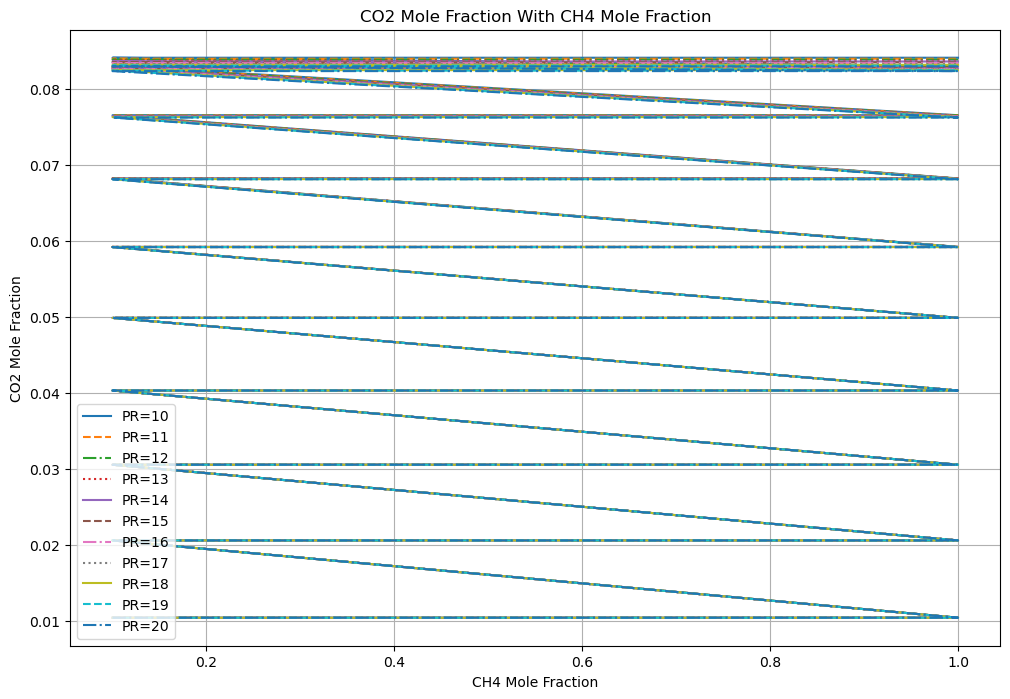

Maximum CO2 Mole Fraction': 0.08412736120328208
Minimum CO2 Mole Fraction': 0.0103909084551334


In [24]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure(figsize=(12, 8))
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.CH4_Mole_Fraction, df_temp.CO2_Mole_Fraction, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('CH4 Mole Fraction')
plt.ylabel('CO2 Mole Fraction')
plt.title('CO2 Mole Fraction With CH4 Mole Fraction')
plt.grid()
plt.show()

Max_CO2_Mole_Fraction = Simulation_Results_df['CO2_Mole_Fraction'].max()
print(f"Maximum CO2 Mole Fraction': {Max_CO2_Mole_Fraction}")

Min_CO2_Mole_Fraction = Simulation_Results_df['CO2_Mole_Fraction'].min()
print(f"Minimum CO2 Mole Fraction': {Min_CO2_Mole_Fraction}")

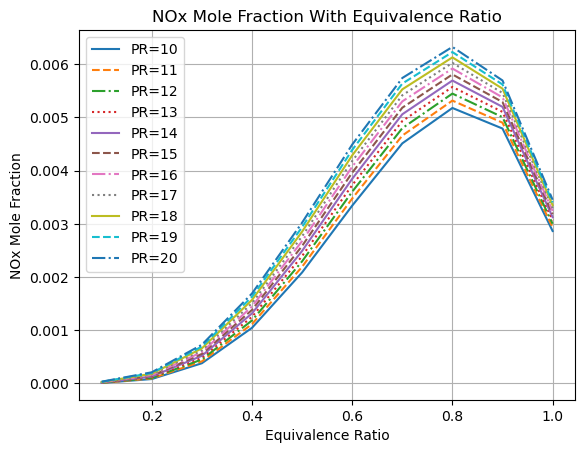

Maximum NOx Mole Fraction': 0.006327332286531406
Minimum NOx Mole Fraction': 7.477845617662844e-06
Temperature_of_Combustion_Gases_At_Equivalence_Ratio_of_0.8': 2308.495193233593


In [25]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.NOx_Mole_Fraction, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('NOx Mole Fraction')
plt.title('NOx Mole Fraction With Equivalence Ratio')
plt.grid()
plt.show()

Max_NOx_Mole_Fraction = Simulation_Results_df['NOx_Mole_Fraction'].max()
print(f"Maximum NOx Mole Fraction': {Max_NOx_Mole_Fraction}")

Min_NOx_Mole_Fraction = Simulation_Results_df['NOx_Mole_Fraction'].min()
print(f"Minimum NOx Mole Fraction': {Min_NOx_Mole_Fraction}")

Temperature_of_Combustion_Gases_at_08_Equi_Ratio = Simulation_Results_df.loc[(Simulation_Results_df['Equivalence_Ratio'] == 0.8) & (Simulation_Results_df['NOx_Mole_Fraction'] == Max_NOx_Mole_Fraction), 'Actual_Combustion_Temperature'].iloc[0]
print(f"Temperature_of_Combustion_Gases_At_Equivalence_Ratio_of_0.8': {Temperature_of_Combustion_Gases_at_08_Equi_Ratio}")

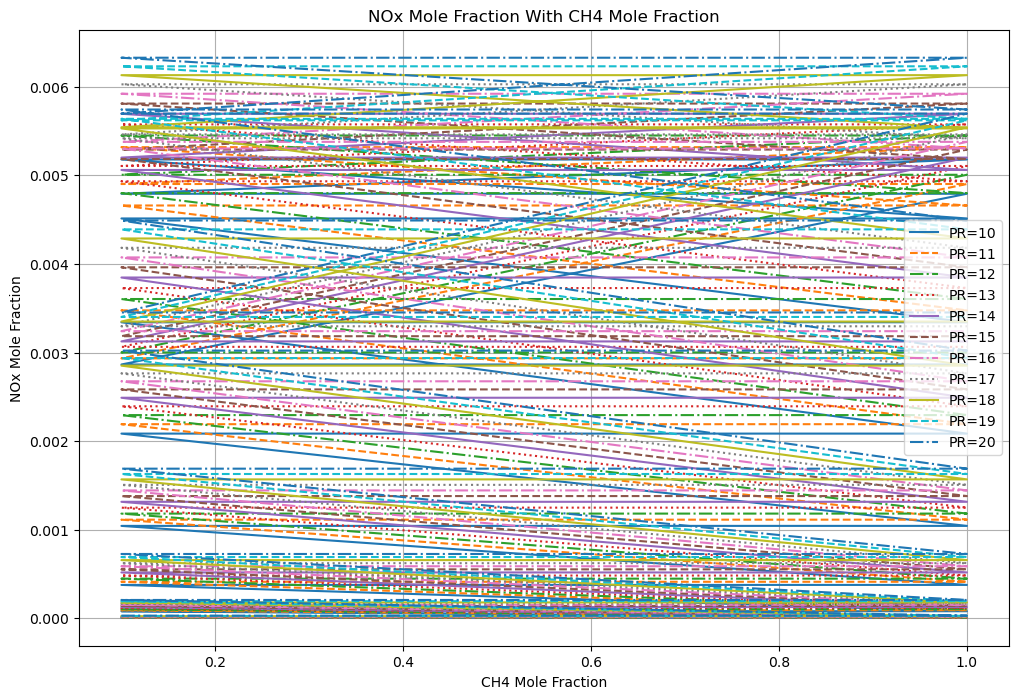

Maximum NOx Mole Fraction': 0.006327332286531406
Minimum NOx Mole Fraction': 7.477845617662844e-06


In [26]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure(figsize=(12, 8))
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.CH4_Mole_Fraction, df_temp.NOx_Mole_Fraction, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('CH4 Mole Fraction')
plt.ylabel('NOx Mole Fraction')
plt.title('NOx Mole Fraction With CH4 Mole Fraction')
plt.grid()
plt.show()

Max_NOx_Mole_Fraction = Simulation_Results_df['NOx_Mole_Fraction'].max()
print(f"Maximum NOx Mole Fraction': {Max_NOx_Mole_Fraction}")

Min_NOx_Mole_Fraction = Simulation_Results_df['NOx_Mole_Fraction'].min()
print(f"Minimum NOx Mole Fraction': {Min_NOx_Mole_Fraction}")

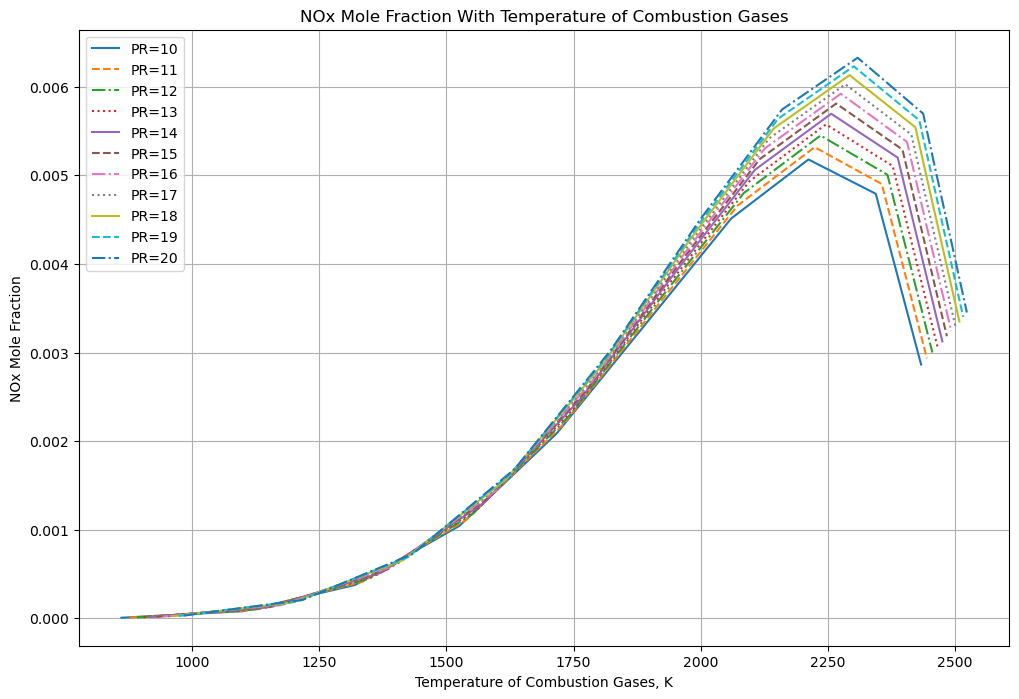

Maximum NOx Mole Fraction': 0.006327332286531406
Minimum NOx Mole Fraction': 7.477845617662844e-06


In [27]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure(figsize=(12, 8))
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Actual_Combustion_Temperature, df_temp.NOx_Mole_Fraction, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Temperature of Combustion Gases, K')
plt.ylabel('NOx Mole Fraction')
plt.title('NOx Mole Fraction With Temperature of Combustion Gases')
plt.grid()
plt.show()

Max_NOx_Mole_Fraction = Simulation_Results_df['NOx_Mole_Fraction'].max()
print(f"Maximum NOx Mole Fraction': {Max_NOx_Mole_Fraction}")

Min_NOx_Mole_Fraction = Simulation_Results_df['NOx_Mole_Fraction'].min()
print(f"Minimum NOx Mole Fraction': {Min_NOx_Mole_Fraction}")

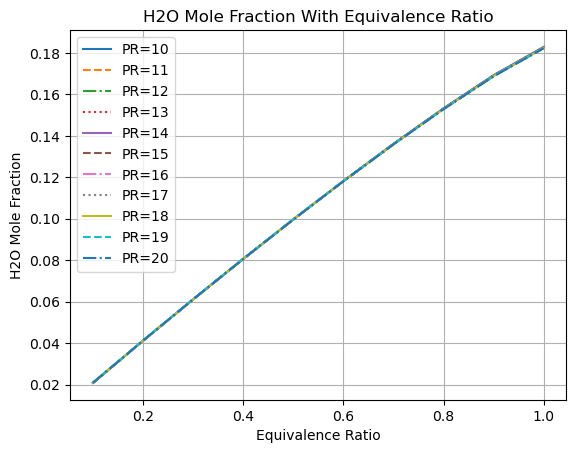

Maximum H2O Mole Fraction': 0.18294067637252473
Minimum H2O Mole Fraction': 0.020781816262776778


In [28]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.H2O_Mole_Fraction, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('H2O Mole Fraction')
plt.title('H2O Mole Fraction With Equivalence Ratio')
plt.grid()
plt.show()

Max_H2O_Mole_Fraction = Simulation_Results_df['H2O_Mole_Fraction'].max()
print(f"Maximum H2O Mole Fraction': {Max_H2O_Mole_Fraction}")

Min_H2O_Mole_Fraction = Simulation_Results_df['H2O_Mole_Fraction'].min()
print(f"Minimum H2O Mole Fraction': {Min_H2O_Mole_Fraction}")

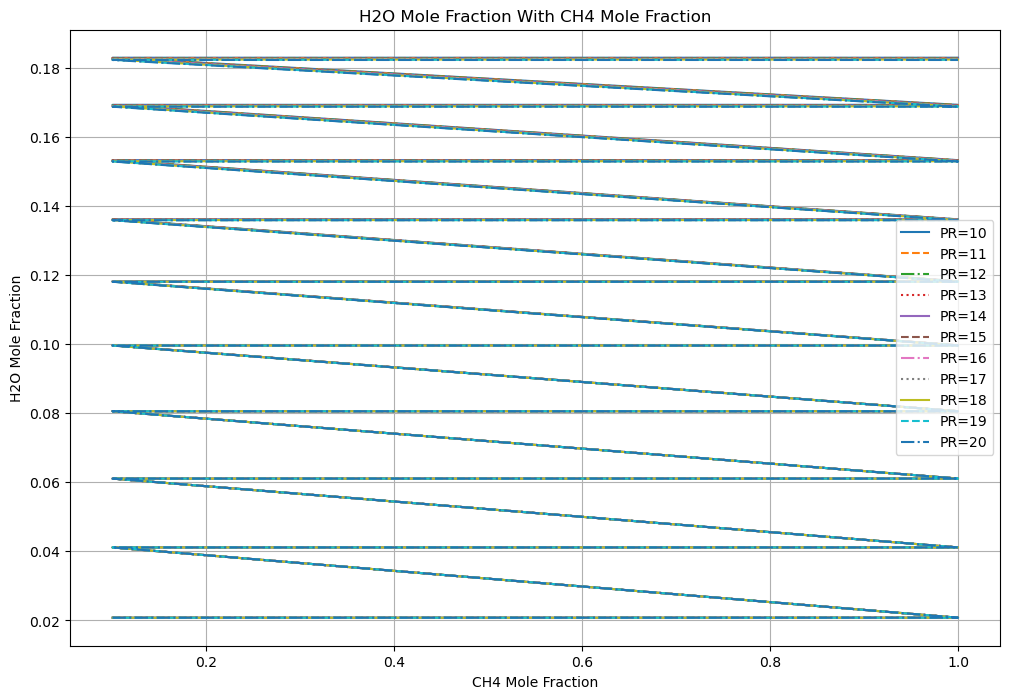

Maximum H2O Mole Fraction': 0.18294067637252473
Minimum H2O Mole Fraction': 0.020781816262776778


In [29]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure(figsize=(12, 8))
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.CH4_Mole_Fraction, df_temp.H2O_Mole_Fraction, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('CH4 Mole Fraction')
plt.ylabel('H2O Mole Fraction')
plt.title('H2O Mole Fraction With CH4 Mole Fraction')
plt.grid()
plt.show()

Max_H2O_Mole_Fraction = Simulation_Results_df['H2O_Mole_Fraction'].max()
print(f"Maximum H2O Mole Fraction': {Max_H2O_Mole_Fraction}")

Min_H2O_Mole_Fraction = Simulation_Results_df['H2O_Mole_Fraction'].min()
print(f"Minimum H2O Mole Fraction': {Min_H2O_Mole_Fraction}")

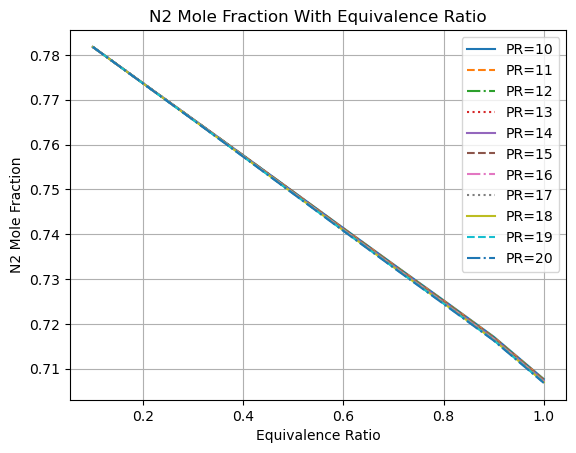

Maximum N2 Mole Fraction': 0.7817884194978637
Minimum N2 Mole Fraction': 0.7068121594432303


In [30]:
lstyles = ["-", "--", "-.", ":","-", "--", "-.", ":","-", "--", "-.", ":"]
fig = plt.figure()
vals = list(set(Simulation_Results_df.Pressure_Ratio.values))
c = 0
for v in vals:
    df_temp = Simulation_Results_df[Simulation_Results_df.Pressure_Ratio==v].copy()
    plt.plot(df_temp.Equivalence_Ratio, df_temp.N2_Mole_Fraction, label=f"PR={v}",ls=lstyles[c])
    c+=1
plt.legend()
plt.xlabel('Equivalence Ratio')
plt.ylabel('N2 Mole Fraction')
plt.title('N2 Mole Fraction With Equivalence Ratio')
plt.grid()
plt.show()

Max_N2_Mole_Fraction = Simulation_Results_df['N2_Mole_Fraction'].max()
print(f"Maximum N2 Mole Fraction': {Max_N2_Mole_Fraction}")

Min_N2_Mole_Fraction = Simulation_Results_df['N2_Mole_Fraction'].min()
print(f"Minimum N2 Mole Fraction': {Min_N2_Mole_Fraction}")

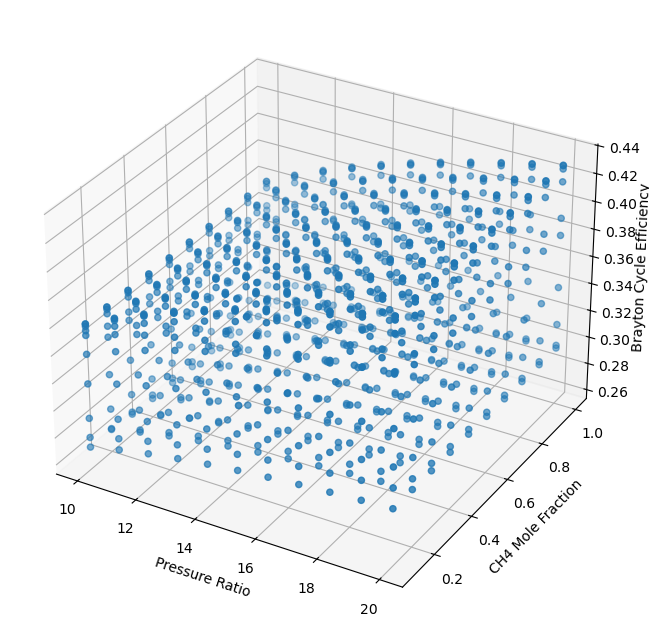

In [31]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(xs=Simulation_Results_df.Pressure_Ratio, ys=Simulation_Results_df.Mole_Fraction_of_Methane, zs=Simulation_Results_df.Cycle_Efficiency)
# Add axis labels
ax.set_xlabel('Pressure Ratio')
ax.set_ylabel('CH4 Mole Fraction')
ax.set_zlabel('Brayton Cycle Efficiency', labelpad=1)
plt.show()